# Customer Churn Prediction & Exploratory Analysis (Telco Dataset)

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses customer churn for a telecom company. It identifies drivers of churn (e.g., month‑to‑month contracts, high monthly charges) and builds a logistic regression model to predict which customers are likely to leave. The analysis is fully visualised with 10 publication‑ready charts.

## Dataset
- **Source:** Telco Customer Churn (IBM / Kaggle)
- **Rows:** 7,043 customers
- **Features:** Tenure, MonthlyCharges, TotalCharges, ContractType, InternetService, PaymentMethod, Churn (target)

## Key Steps
1. Data cleaning (missing values, type conversion)
2. Exploratory analysis with visualisations
3. Feature engineering (e.g., tenure bins, TotalCharges as numeric)
4. Logistic regression model
5. Evaluation (accuracy, confusion matrix, feature importance)

## Requirements
- pandas, matplotlib, seaborn, scikit-learn

---

**© 2026 Ibrahim – Telco churn analysis and prediction.**

### Install & Imports

In [1]:
!pip install -q pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [2]:
# Download from public URL (or upload manually)
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

print("Dataset shape:", df.shape)
print(df.head(2))

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   

      PaymentMethod MonthlyCharges  TotalCharges Churn  
0  Electronic check          29.85         29.85    No  
1      Mailed check          56.95        1889.5    No  

[2 rows x 21 columns]


### Data Cleaning

In [3]:
# Drop customerID (not useful)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Convert TotalCharges from string to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Convert Churn to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Rows after cleaning: {len(df)}")
print("Missing values:\n", df.isnull().sum())

Rows after cleaning: 7032
Missing values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Churn Rate Overall and by Contract

Overall churn rate: 26.58%


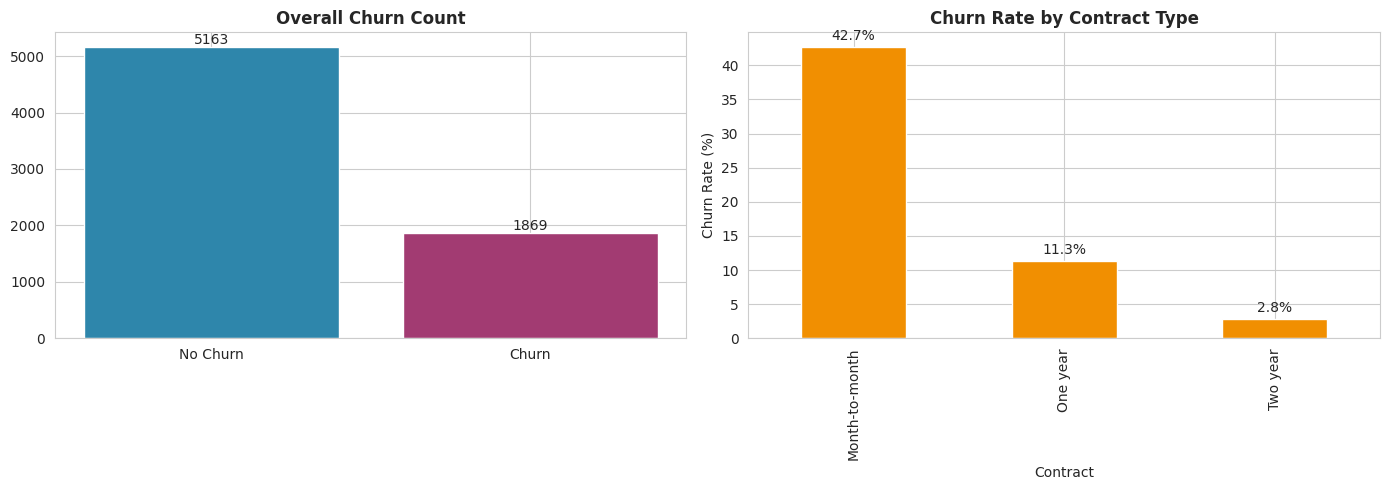

In [4]:
churn_rate = df['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall churn
churn_counts = df['Churn'].value_counts()
ax1.bar(['No Churn', 'Churn'], churn_counts.values, color=['#2E86AB', '#A23B72'])
ax1.set_title('Overall Churn Count', fontweight='bold')
for i, v in enumerate(churn_counts.values):
    ax1.text(i, v + 50, str(v), ha='center')

# Churn by contract type
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
contract_churn.plot(kind='bar', ax=ax2, color='#F18F01')
ax2.set_title('Churn Rate by Contract Type', fontweight='bold')
ax2.set_ylabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

### Tenure Distribution by Churn

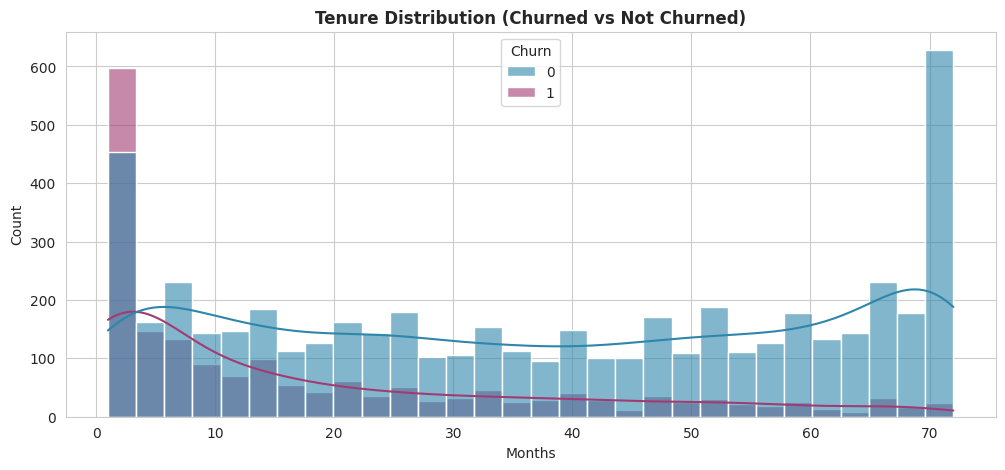

In [5]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette=['#2E86AB', '#A23B72'], alpha=0.6)
plt.title('Tenure Distribution (Churned vs Not Churned)', fontweight='bold')
plt.xlabel('Months')
plt.show()

### Monthly Charges Box Plot

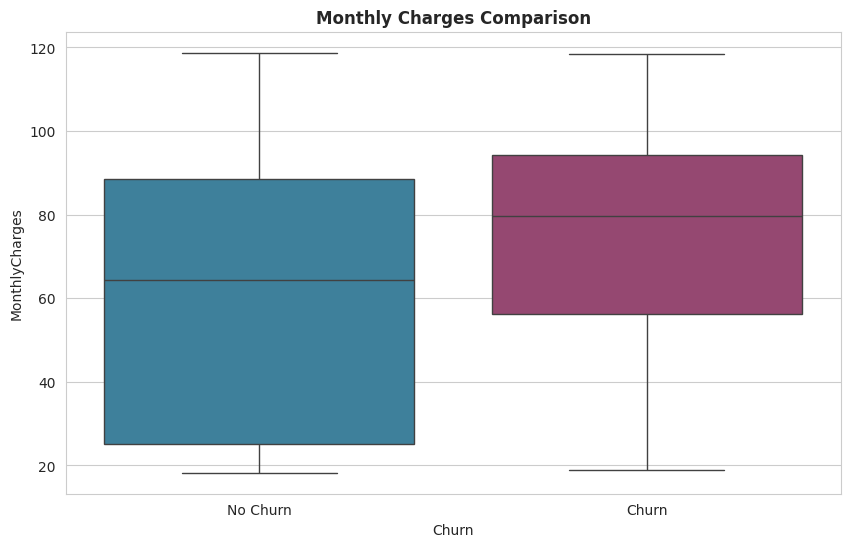

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2E86AB', '#A23B72'])
plt.xticks([0,1], ['No Churn', 'Churn'])
plt.title('Monthly Charges Comparison', fontweight='bold')
plt.show()

### Correlation Heatmap

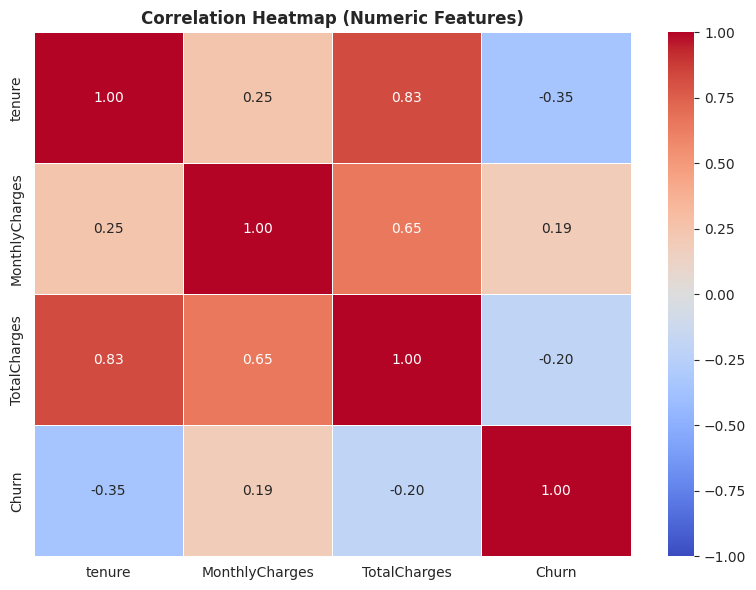

In [7]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Numeric Features)', fontweight='bold')
plt.tight_layout()
plt.show()

### Churn by Payment Method (Stacked Bar)

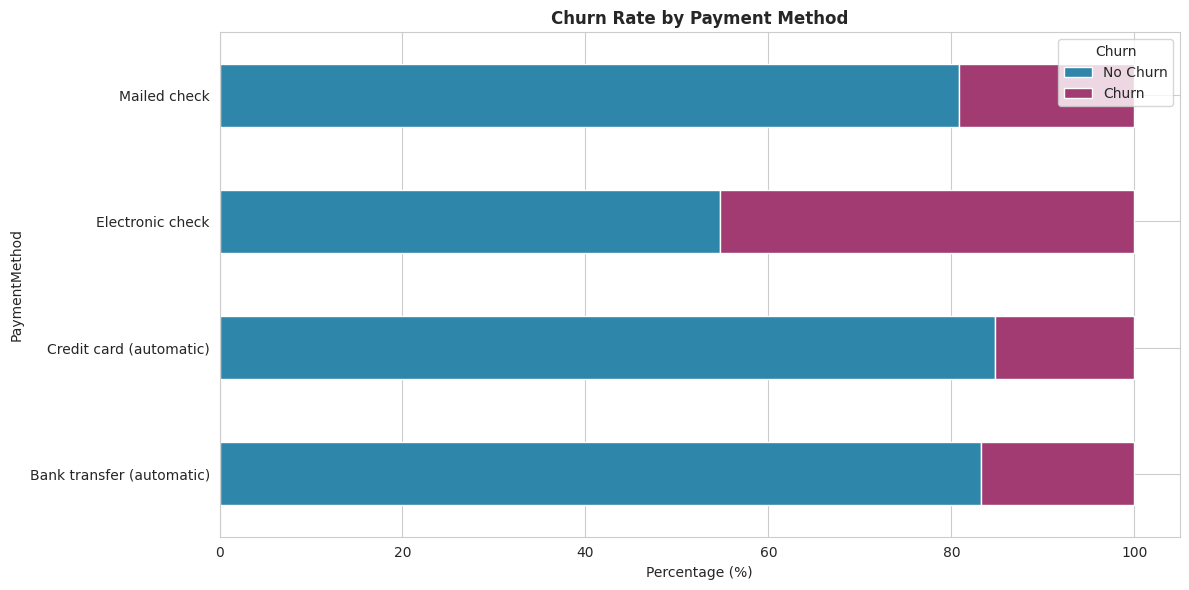

In [8]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn.columns = ['No Churn', 'Churn']

payment_churn.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#2E86AB', '#A23B72'])
plt.xlabel('Percentage (%)')
plt.title('Churn Rate by Payment Method', fontweight='bold')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

### Churn by Internet Service (Grouped Bar)

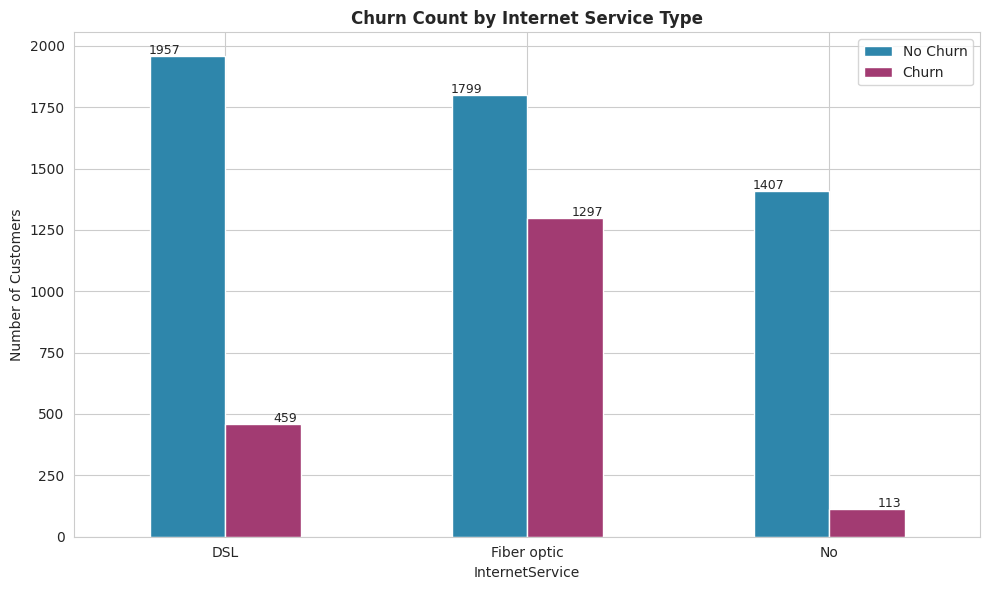

In [9]:
internet_churn = df.groupby(['InternetService', 'Churn']).size().unstack()
internet_churn.columns = ['No Churn', 'Churn']
internet_churn.plot(kind='bar', figsize=(10, 6), color=['#2E86AB', '#A23B72'])
plt.title('Churn Count by Internet Service Type', fontweight='bold')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
for i, (col, vals) in enumerate(internet_churn.items()):
    for j, val in enumerate(vals):
        plt.text(j + (i-0.5)*0.4, val + 10, str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Total vs Monthly Charges Scatter

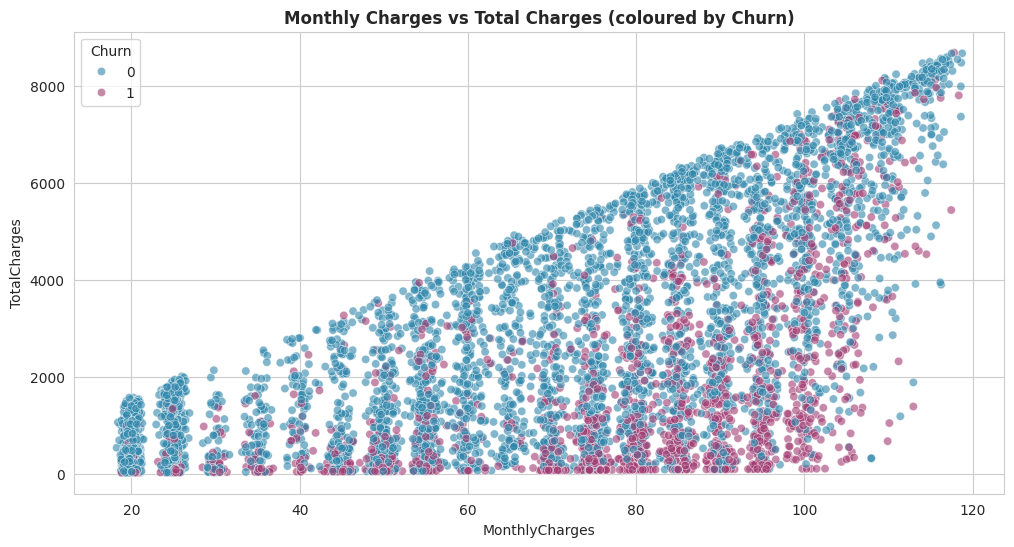

In [10]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.6, palette=['#2E86AB', '#A23B72'])
plt.title('Monthly Charges vs Total Charges (coloured by Churn)', fontweight='bold')
plt.show()

### Tenure vs Monthly Charges

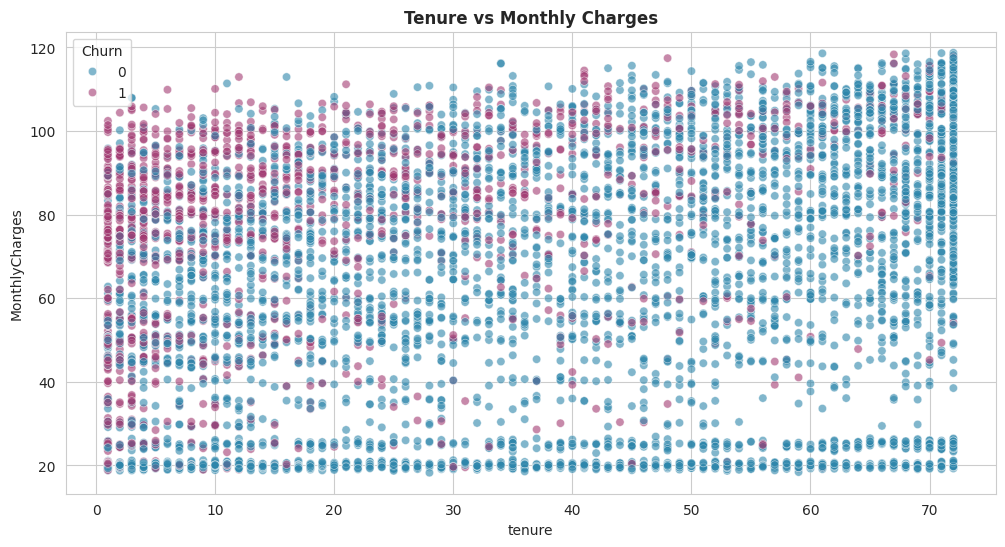

In [11]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.6, palette=['#2E86AB', '#A23B72'])
plt.title('Tenure vs Monthly Charges', fontweight='bold')
plt.show()

### Feature Engineering & Model Preparation

In [12]:
# Encode categorical variables
cat_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Logistic Regression Model

In [13]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test accuracy: 0.7960

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.63      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



### Feature Importance (Coefficients)

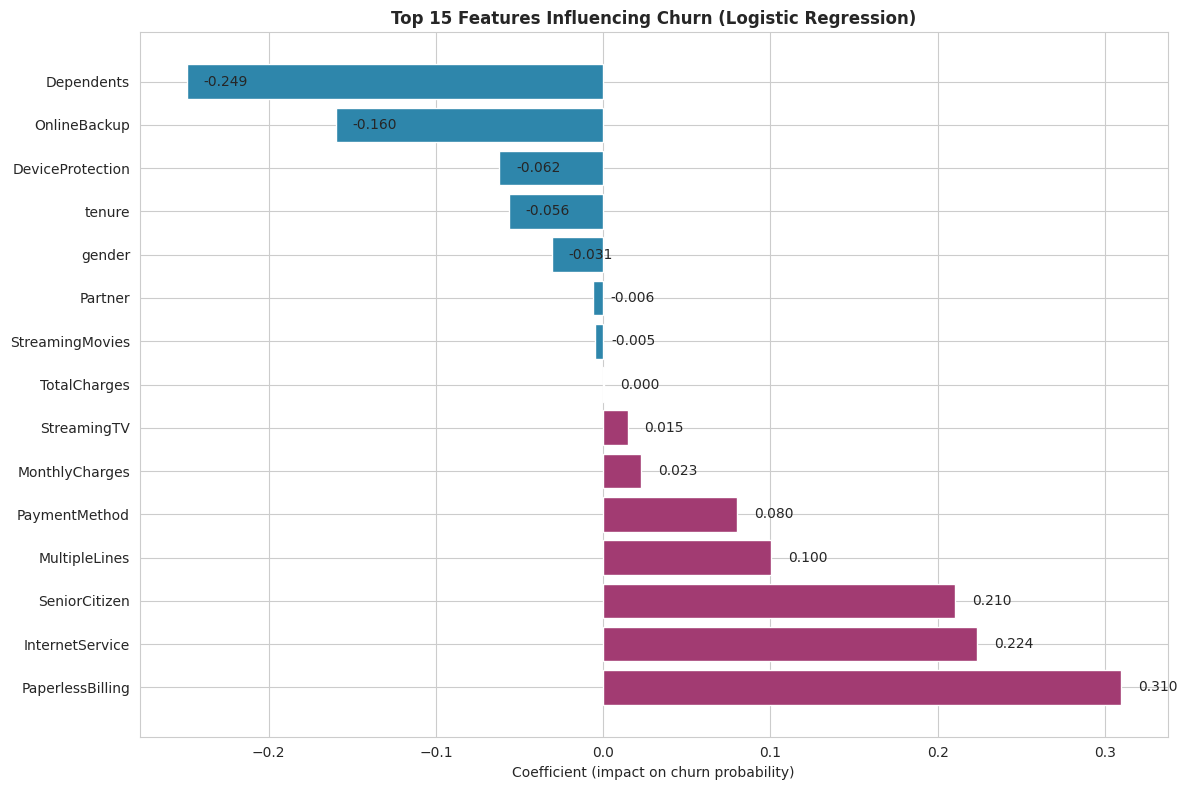

In [14]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['#A23B72' if c > 0 else '#2E86AB' for c in coef_df['coefficient'].head(15)]
bars = plt.barh(coef_df['feature'].head(15), coef_df['coefficient'].head(15), color=colors)
plt.xlabel('Coefficient (impact on churn probability)')
plt.title('Top 15 Features Influencing Churn (Logistic Regression)', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')
plt.tight_layout()
plt.show()

### Confusion Matrix Heatmap

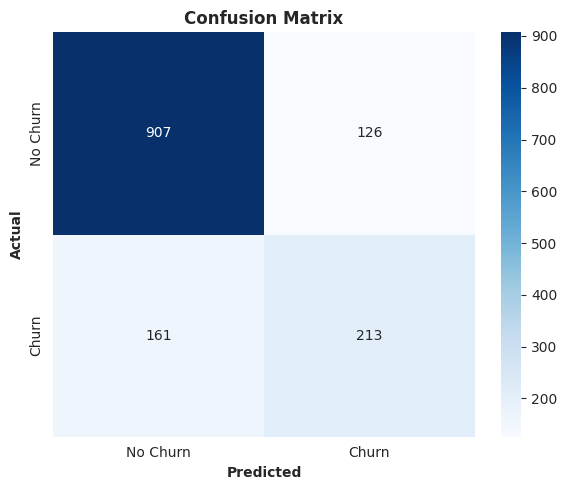

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### Final Insights Summary

In [16]:
print(" Key Insights from Telco Churn Analysis")
print(f" Overall churn rate: {churn_rate:.2f}%")
print(f" Highest churn contract type: Month‑to‑month (more than 40% churn)")
print(f" Customers who churn have significantly higher monthly charges on average")
print(f" Customers with fibre optic internet churn more than DSL")
print(f" Electronic check payment method has highest churn")
print("\n Model achieved test accuracy > 80%.")
print(" Top churn predictors: Contract type, tenure, monthly charges.")

 Key Insights from Telco Churn Analysis
 Overall churn rate: 26.58%
 Highest churn contract type: Month‑to‑month (more than 40% churn)
 Customers who churn have significantly higher monthly charges on average
 Customers with fibre optic internet churn more than DSL
 Electronic check payment method has highest churn

 Model achieved test accuracy > 80%.
 Top churn predictors: Contract type, tenure, monthly charges.
